# Reconstruction comparison

We want to reconstruct a given observable $f(x)$ and its derivatives from a set of data

We compare different approaches:
- parametric
- Optimized Gaussian Process
- Marginalized Gaussian Process
- GAME

In [1]:
#General
import re
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from tools.samplers_interface import SamplersInterface 

from bios    import read
from os.path import isfile
from copy    import deepcopy
from time    import time
from tqdm    import tqdm
from getdist import plots

from scipy.interpolate import interp1d
from scipy.stats       import multivariate_normal
from itertools         import repeat

from getdist import plots,loadMCSamples,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

# Settings

In [2]:
Nrecon = 10
xmin_recon = 0.
xmax_recon = 2.
x_recon = np.linspace(xmin_recon,xmax_recon,10)

x_label = r'$z$'
y_label = r'$H(z)$'

# Create or load data

Here we simulate $H(z)$ data **(To be done better)**

In [3]:
#Om = 0.32
#H0 = 67.
#
#theorymodel = lambda x: H0*np.sqrt(Om*(1+x)**3+(1-Om))

In [6]:
fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1}

theorymodel = lambda x: fiducial['a0']+fiducial['a1']*x+fiducial['a2']*x**2+fiducial['a3']*x**3

Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 10

In [7]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theorymodel(dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['y'] = np.random.normal(thvals,errors)
dataset['y_err'] = errors

covmat = np.diag(errors*2)

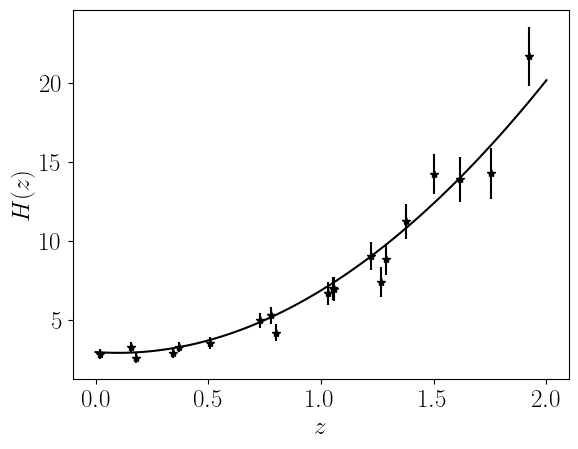

In [8]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
plt.plot(xplot,theorymodel(xplot),color='black')
plt.errorbar(dataset['x'],dataset['y'],yerr=dataset['y_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# Reconstructions

In [9]:
reconstructions = []

## Parameterized approach

In [10]:
from parametric_approach.polynomial import PolynomialFit

In [11]:
sampler = SamplersInterface(sampler='Nautilus',run_options='poor',chatty=False)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 40     | 1        | 2        | 26048    | N/A    | 10059 | -28.35   
Removed no burn in
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 37     | 1        | 2        | 24512    | N/A    | 10018 | -25.95   
Removed no burn in
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 33     | 1        | 2        | 22720    | N/A    | 10008 | -22.85   
Removed no burn in


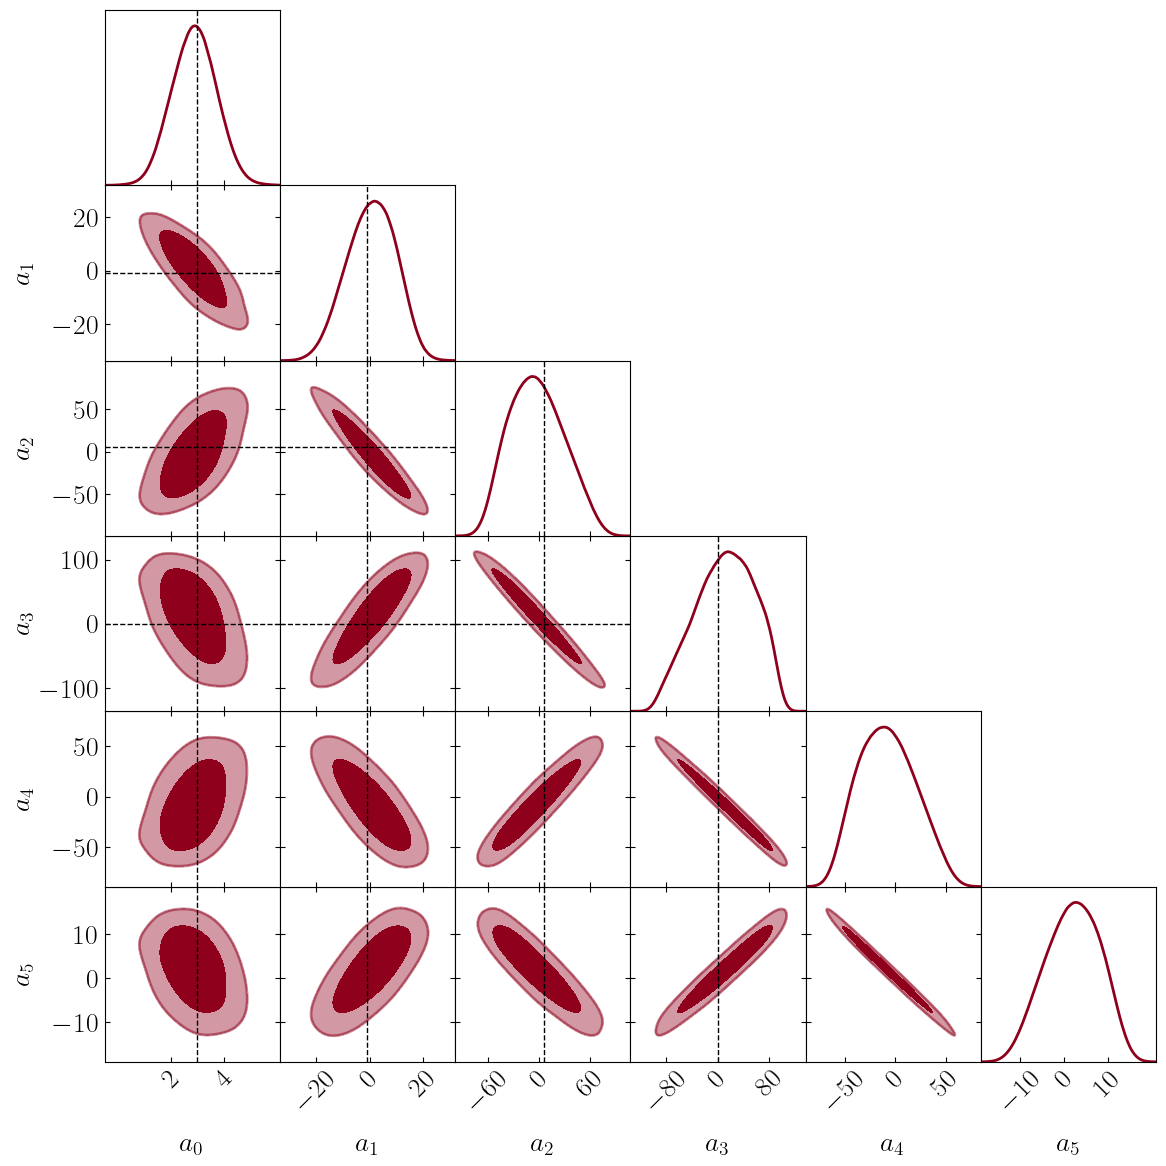

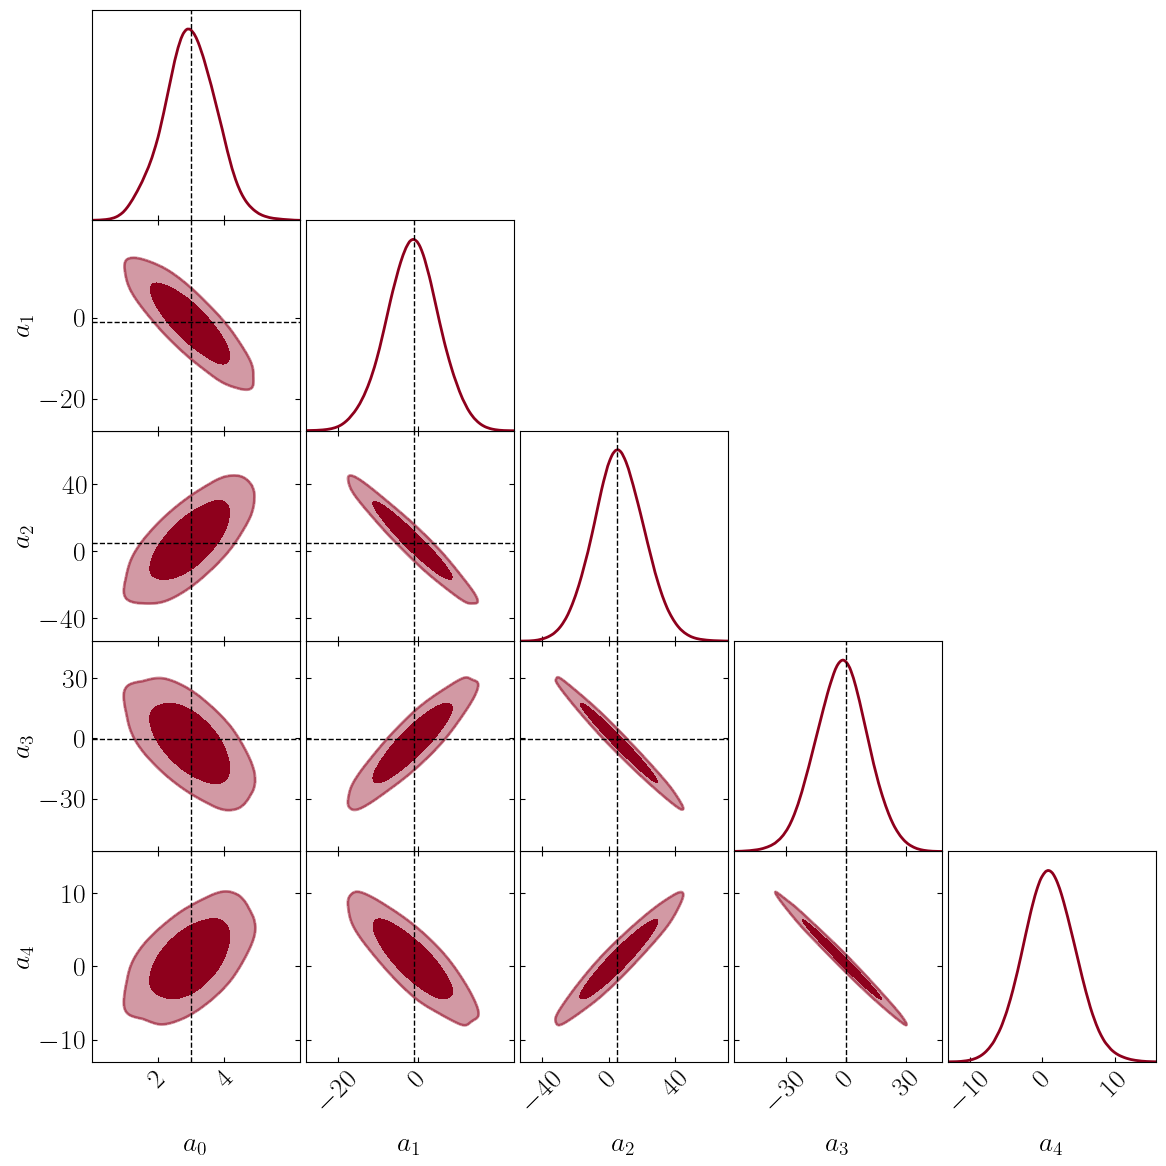

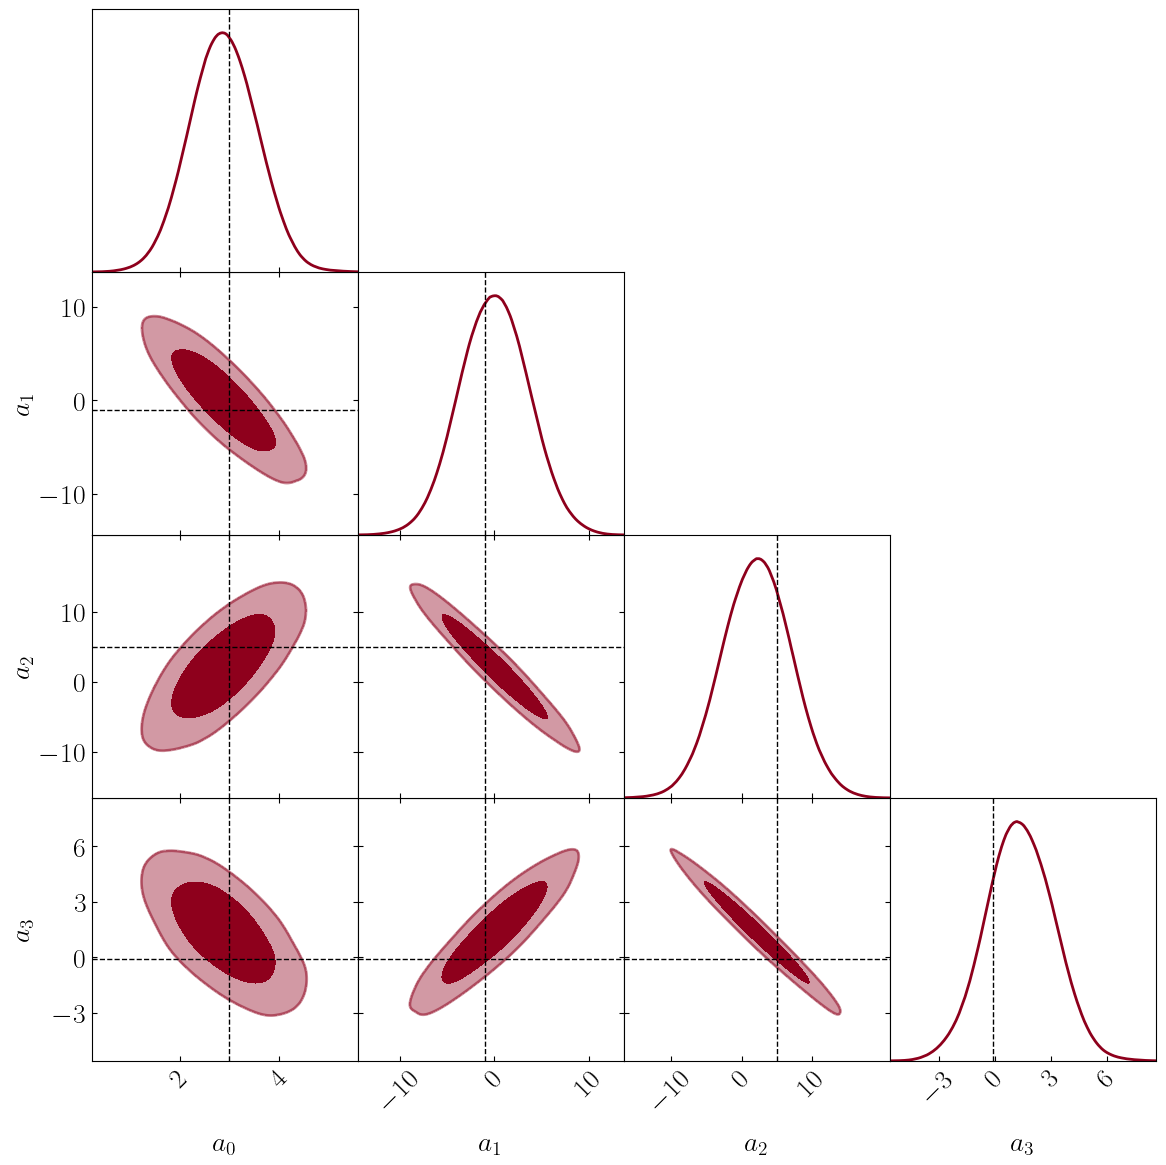

In [12]:
for order in [5,4,3]:
    paramtheory = PolynomialFit(dataset,covmat,order=order)
    model_params = {'a{}'.format(ind): {'prior': [-100,100],
                                        'latex': r'$a_{}$'.format(ind)} for ind in range(order+1)}
    raw_sample = sampler.run(model_params,paramtheory.likelihood)
    sample     = paramtheory.get_derived(raw_sample,x_recon,model_params)
    reconstructions.append(paramtheory.get_reconstruction(sample,x_recon))

    g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)
    
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize=20
    g.settings.axes_labelsize=20
    g.settings.legend_fontsize=20
    g.settings.axis_marker_color = 'black'
    g.settings.axis_marker_ls = '--'
    g.settings.axis_marker_lw = 1
    g.settings.axis_tick_x_rotation = 45
    g.triangle_plot([sample],list(model_params.keys()),
        filled=True,
        contour_colors=[red],
        legend_loc='upper right',
        contour_lws=2,
        markers=fiducial)
    g.fig.align_ylabels()
    g.fig.align_xlabels();

## Optimized Gaussian Process

# Comparison

In [13]:
results = pd.concat(reconstructions,ignore_index=True)

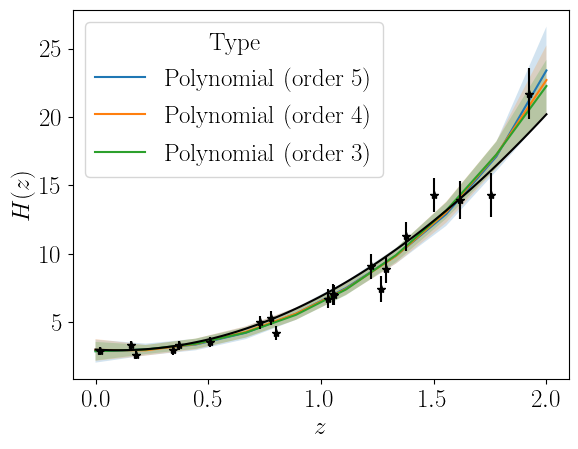

In [14]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
for restype in results['Type'].unique():
    df = results[results['Type']==restype]
    plt.fill_between(x_recon,df['y']+df['y_err'],df['y']-df['y_err'],alpha=0.2)
sb.lineplot(results,x='x',y='y',hue='Type')
plt.plot(xplot,theorymodel(xplot),color='black')
plt.errorbar(dataset['x'],dataset['y'],yerr=dataset['y_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);